<a href="https://colab.research.google.com/github/mohammadabuhamed2/binx_mohammadabuhamed/blob/main/day2_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 — Building CNNs & Transfer Learning

## Connect Google Drive

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


### Download the Dataset from Kaggle

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant"
)

print(path)

Using Colab cache for faster access to the 'melanoma-skin-cancer-dataset-benign-vs-malignant' dataset.
/kaggle/input/melanoma-skin-cancer-dataset-benign-vs-malignant


### Save the Dataset to Google Drive

In [ ]:
import shutil

shutil.copytree(
    path,
    "/content/drive/MyDrive/binx_training/day2_week7/melanoma_dataset",
    dirs_exist_ok=True
)

KeyboardInterrupt: 

### Set Dataset Paths

In [3]:
train_path = path + "/train"
test_path = path + "/test"

### Import Libraries

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

### Load the Training Dataset

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    label_mode="binary"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32,
    label_mode="binary"
)
test_ds=tf.keras.utils.image_dataset_from_directory(
   test_path,
   image_size=(128,128),
   batch_size=32,
   seed=42,
   label_mode="binary"
)

Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.


### Check Class Names

In [6]:
class_names = train_ds.class_names

print(class_names)

['Benign', 'Malignant']


## Step 1: Build and Train a CNN from Scratch

### Normalize Image Pixel Values

Pixel values normally range from 0 to 255.

We rescale them to the range 0 to 1 to make training more stable and efficient.

`new_pixel = old_pixel / 255`

In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

### Build the CNN Model

In [15]:
model=tf.keras.Sequential([

  tf.keras.Input(shape=(128,128,3)),
  normalization_layer,
  tf.keras.layers.Conv2D(32,(3,3),padding='same',activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64,(3,3),padding='same',activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(64,activation='relu'),
  tf.keras.layers.Dense(1,activation='sigmoid')
])

### Display the Model Architecture

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,825 (16.07 MB)

 Trainable params: 4,213,825 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the CNN Model

In [16]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",tf.keras.metrics.Recall(name="recall")]
)



### Configure Early Stopping

In [17]:
early_stoping=tf.keras.callbacks.EarlyStopping(
    monitor="val_recall",
    patience=10,
    restore_best_weights=True
)

### Configure Model Checkpoint

In [18]:
check_point=tf.keras.callbacks.ModelCheckpoint(
    "melanoma_cnn_model.keras",
    monitor="val_recall",
    save_best_only=True
)

### Train the CNN Model

In [20]:
history=model.fit(train_ds,validation_data=val_ds,epochs=100,callbacks=[early_stoping,check_point])

Epoch 1/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.7750 - loss: 0.4586 - recall: 0.6875 - val_accuracy: 0.8131 - val_loss: 0.3960 - val_recall: 0.6716
Epoch 2/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8376 - loss: 0.3535 - recall: 0.8081 - val_accuracy: 0.8488 - val_loss: 0.3394 - val_recall: 0.8358
Epoch 3/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8562 - loss: 0.3274 - recall: 0.8396 - val_accuracy: 0.8455 - val_loss: 0.3347 - val_recall: 0.8087
Epoch 4/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.8563 - loss: 0.3200 - recall: 0.8394 - val_accuracy: 0.8455 - val_loss: 0.3386 - val_recall: 0.8148
Epoch 5/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8726 - loss: 0.2943 - recall: 0.8650 - val_accuracy: 0.8417 - val_loss: 0.3690 - val_recall: 0.8061
Epoch 6/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8787 - loss: 0.2823 - recall: 0.8688 - val_accuracy: 0.8678 - val_loss: 0.3170 - val_recal

### Plot Training and Validation Accuracy

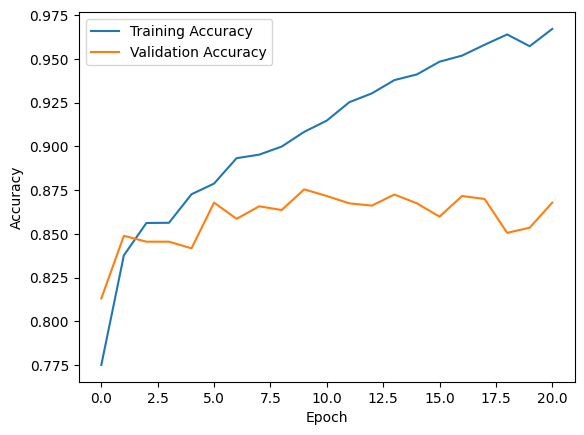

In [21]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Training vs Validation Accuracy

The training accuracy continued to increase, while the validation accuracy stopped improving and remained around the same level.

This gap between training and validation performance indicates overfitting.

The model is learning the training images very well, but its ability to generalize to unseen validation images is not improving at the same rate.

### Plot Training and Validation Loss

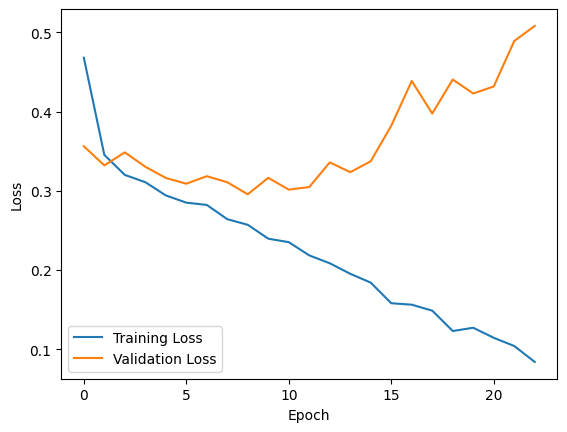

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Training vs Validation Loss

The training loss continued to decrease throughout training.

However, the validation loss decreased at first and then started to increase after several epochs.

This indicates overfitting, because the model continued improving on the training data while its performance on unseen validation data became worse.

### Plot Training and Validation Recall

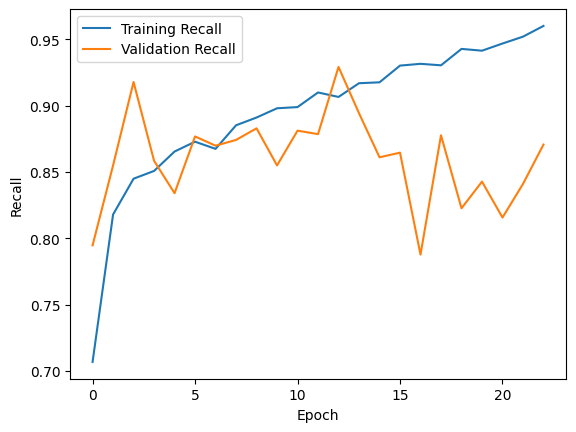

In [ ]:
plt.plot(history.history["recall"], label="Training Recall")
plt.plot(history.history["val_recall"], label="Validation Recall")

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()
plt.show()

### Training vs Validation Recall

The training recall continued to improve throughout training.

However, the validation recall became unstable and fluctuated across epochs.

This gap between training and validation recall is another sign of overfitting, where the model performs better on the training data than on unseen validation data.

### Evaluate the CNN Model

In [ ]:
test_loss, test_accuracy, test_recall = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Recall:", test_recall)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8870 - loss: 0.2999 - recall: 0.9390
Test Loss: 0.29990628361701965
Test Accuracy: 0.8870000243186951
Test Recall: 0.9390000104904175


### CNN From Scratch Results

The CNN model was evaluated on the test dataset.

- **Test Accuracy:** 88.70%
- **Test Recall:** 93.90%
- **Test Loss:** 0.2999

The model achieved high recall, meaning it was able to correctly detect most of the malignant cases.

The accuracy is also strong, showing that the model classified most test images correctly overall.

## Step 2: Add Data Augmentation

In [8]:
data_augmentation=tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2)


])

### Build the CNN Model with Data Augmentation

In [9]:
aug_model=tf.keras.Sequential([
    tf.keras.Input(shape=(128,128,3)),
    data_augmentation,
    normalization_layer,
    tf.keras.layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')


])

### Compile the Augmented CNN Model

In [10]:
aug_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',tf.keras.metrics.Recall(name='recall')]
)

### Configure Early Stopping and Model Checkpoint

In [11]:
early_stoping=tf.keras.callbacks.EarlyStopping(
    monitor='val_recall',
    patience=10,
    restore_best_weights=True
)
check_point=tf.keras.callbacks.ModelCheckpoint(
    'melanoma_aug_cnn_model.keras',
    monitor='val_recall',
    save_best_only=True
)

### Train the CNN Model with Data Augmentation

In [12]:
aug_model_history=aug_model.fit(train_ds,validation_data=val_ds,epochs=100,callbacks=[early_stoping,check_point])

Epoch 1/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.7528 - loss: 0.5275 - recall: 0.6551 - val_accuracy: 0.8219 - val_loss: 0.3885 - val_recall: 0.8472
Epoch 2/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.8247 - loss: 0.3956 - recall: 0.8043 - val_accuracy: 0.8366 - val_loss: 0.3582 - val_recall: 0.8288
Epoch 3/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8309 - loss: 0.3830 - recall: 0.8223 - val_accuracy: 0.8434 - val_loss: 0.3663 - val_recall: 0.9092
Epoch 4/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.8379 - loss: 0.3711 - recall: 0.8283 - val_accuracy: 0.8429 - val_loss: 0.3691 - val_recall: 0.9127
Epoch 5/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8444 - loss: 0.3612 - recall: 0.8405 - val_accuracy: 0.8514 - val_loss: 0.3291 - val_recall: 0.8463
Epoch 6/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8460 - loss: 0.3507 - recall: 0.8463 - val_accuracy: 0.8535 - val_loss: 0.3306 - val_r

### Compare Validation Accuracy

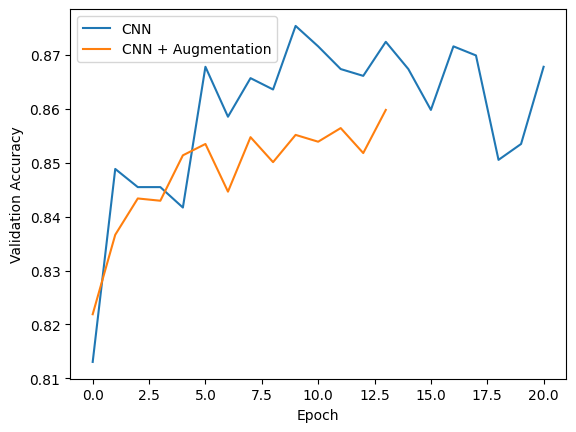

In [22]:
plt.plot(history.history["val_accuracy"], label="CNN")
plt.plot(aug_model_history.history["val_accuracy"], label="CNN + Augmentation")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

### Validation Accuracy Comparison

The CNN without data augmentation achieved slightly higher validation accuracy.

The augmented model showed a more gradual improvement, but its validation accuracy remained slightly lower in this experiment.

Data augmentation does not always increase validation accuracy immediately, but it can help reduce overfitting and improve generalization.

### Compare Validation Loss

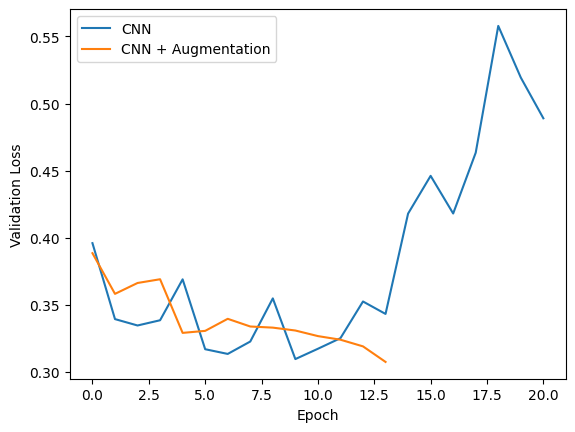

In [23]:
plt.plot(history.history["val_loss"], label="CNN")
plt.plot(aug_model_history.history["val_loss"], label="CNN + Augmentation")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

### Validation Loss Comparison

The CNN without data augmentation started to overfit after several epochs, as its validation loss increased significantly.

The CNN with data augmentation maintained a lower and more stable validation loss.

This shows that data augmentation helped reduce overfitting and improved the model's generalization to unseen data.

### Compare Validation Recall

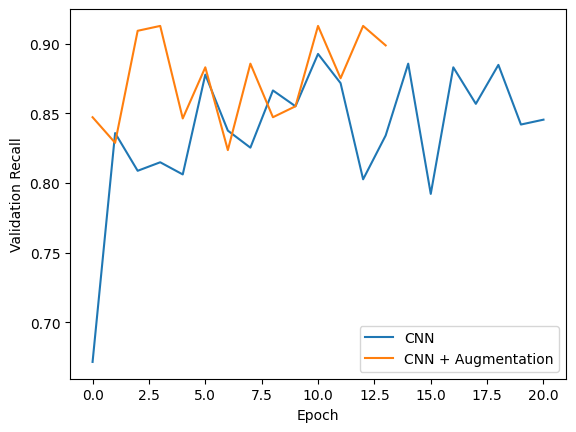

In [24]:
plt.plot(history.history["val_recall"], label="CNN")
plt.plot(aug_model_history.history["val_recall"], label="CNN + Augmentation")

plt.xlabel("Epoch")
plt.ylabel("Validation Recall")
plt.legend()
plt.show()

### Validation Recall Comparison

The CNN with data augmentation achieved higher validation recall in several epochs and showed better performance in detecting positive cases.

The CNN without augmentation showed more fluctuation in validation recall.

This suggests that data augmentation helped the model generalize better and detect more malignant cases on unseen validation data.

### Evaluate the Augmented CNN Model

In [26]:
aug_test_loss, aug_test_accuracy, aug_test_recall = aug_model.evaluate(test_ds)

print("Test Loss:", aug_test_loss)
print("Test Accuracy:", aug_test_accuracy)
print("Test Recall:", aug_test_recall)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8535 - loss: 0.3788 - recall: 0.8940
Test Loss: 0.37877753376960754
Test Accuracy: 0.8535000085830688
Test Recall: 0.8939999938011169


### CNN with Data Augmentation Results

The CNN with data augmentation was evaluated on the test dataset.

- **Test Accuracy:** 85.35%
- **Test Recall:** 89.40%
- **Test Loss:** 0.3788

Compared with the CNN trained without augmentation, the augmented model achieved lower test accuracy and recall in this experiment.

However, the validation curves showed less overfitting, especially in validation loss.

This means that data augmentation improved training stability and generalization behavior, but it did not improve the final test performance in this run.

### CNN Performance Comparison

| Model | Test Accuracy | Test Recall | Test Loss |
|---|---:|---:|---:|
| CNN From Scratch | 88.70% | 93.90% | 0.2999 |
| CNN + Data Augmentation | 85.35% | 89.40% | 0.3788 |

The CNN without data augmentation achieved better final test accuracy, recall, and loss.

However, the CNN with data augmentation showed less overfitting in the validation curves, especially in validation loss.

## Step 3: Apply Transfer Learning

### Load the Pre-trained MobileNetV2 Model

In [69]:
base_model=tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128,128,3),
    weights='imagenet'
)

### Freeze the Pre-trained Layers

In [70]:
base_model.trainable=False

### Build the Transfer Learning Model

In [71]:
transfer_model=tf.keras.Sequential([
    tf.keras.Input(shape=(128,128,3)),
     tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
     tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1,activation='sigmoid')

])

### Compile the Transfer Learning Model

In [72]:
transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall")
    ]
)

### Configure Early Stopping and Model Checkpoint

In [73]:
transfer_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_recall",
    patience=10,
    restore_best_weights=True,
    mode="max"
)

transfer_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "melanoma_transfer_model.keras",
    monitor="val_recall",
    save_best_only=True,
    mode="max"
)

### Train the Transfer Learning Model

In [74]:
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        transfer_early_stopping,
        transfer_checkpoint
    ]
)

Epoch 1/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.8044 - loss: 0.4296 - recall: 0.7744 - val_accuracy: 0.8438 - val_loss: 0.3365 - val_recall: 0.8026
Epoch 2/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8488 - loss: 0.3407 - recall: 0.8256 - val_accuracy: 0.8581 - val_loss: 0.3253 - val_recall: 0.8576
Epoch 3/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8604 - loss: 0.3241 - recall: 0.8353 - val_accuracy: 0.8552 - val_loss: 0.3157 - val_recall: 0.8192
Epoch 4/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8621 - loss: 0.3120 - recall: 0.8423 - val_accuracy: 0.8594 - val_loss: 0.3138 - val_recall: 0.8183
Epoch 5/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8695 - loss: 0.3030 - recall: 0.8452 - val_accuracy: 0.8619 - val_loss: 0.3086 - val_recall: 0.8314
Epoch 6/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8694 - loss: 0.3022 - recall: 0.8484 - val_accuracy: 0.8573 - val_loss: 0.3130 - val_rec

### Compare Validation Accuracy Across Models

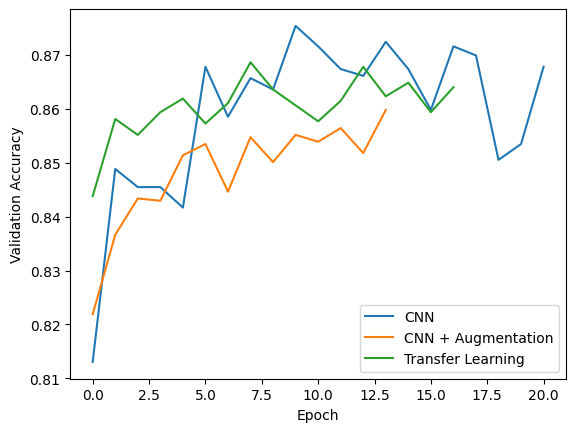

In [75]:
plt.plot(history.history["val_accuracy"], label="CNN")
plt.plot(aug_model_history.history["val_accuracy"], label="CNN + Augmentation")
plt.plot(transfer_history.history["val_accuracy"], label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

### Validation Accuracy Comparison

The CNN from scratch achieved the highest validation accuracy in this experiment.

Transfer Learning achieved a similar and relatively stable validation accuracy, while the CNN with data augmentation had slightly lower validation accuracy.

Although Transfer Learning did not achieve the highest validation accuracy, it remained competitive with the CNN from scratch.

### Compare Validation Loss Across Models

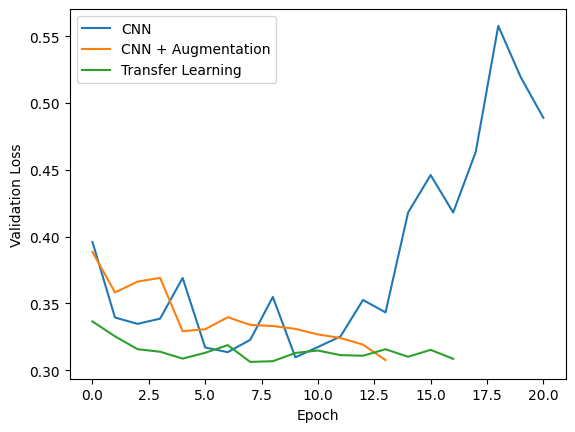

In [76]:
plt.plot(history.history["val_loss"], label="CNN")
plt.plot(aug_model_history.history["val_loss"], label="CNN + Augmentation")
plt.plot(transfer_history.history["val_loss"], label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

### Validation Loss Comparison

The CNN from scratch showed clear overfitting, as its validation loss increased significantly after several epochs.

Both the CNN with data augmentation and the Transfer Learning model maintained lower and more stable validation loss.

The Transfer Learning model showed particularly stable validation loss, indicating better generalization compared with the CNN from scratch.

### Compare Validation Recall Across Models

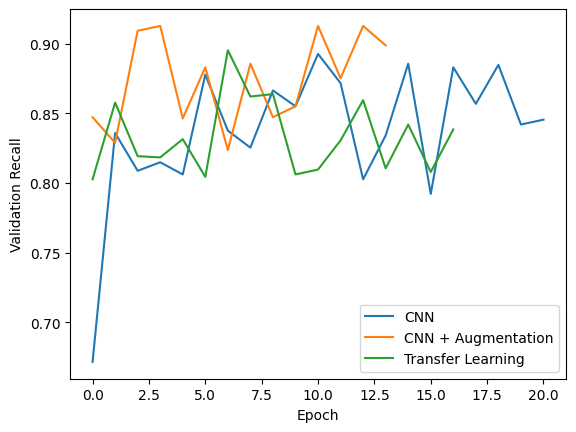

In [77]:
plt.plot(history.history["val_recall"], label="CNN")
plt.plot(aug_model_history.history["val_recall"], label="CNN + Augmentation")
plt.plot(transfer_history.history["val_recall"], label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Recall")
plt.legend()
plt.show()

### Validation Recall Comparison

The CNN with data augmentation achieved the highest validation recall in several epochs.

The CNN from scratch also achieved strong recall but showed noticeable fluctuations.

The Transfer Learning model remained competitive, but its validation recall was generally lower and more variable in this experiment.

### Evaluate the Transfer Learning Model

In [78]:
transfer_test_loss, transfer_test_accuracy, transfer_test_recall = transfer_model.evaluate(test_ds)

print("Test Loss:", transfer_test_loss)
print("Test Accuracy:", transfer_test_accuracy)
print("Test Recall:", transfer_test_recall)

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.8975 - loss: 0.2582 - recall: 0.9050
Test Loss: 0.258219450712204
Test Accuracy: 0.8974999785423279
Test Recall: 0.9049999713897705


### Final Model Comparison

| Model | Test Accuracy | Test Recall | Test Loss |
|---|---:|---:|---:|
| CNN From Scratch | 88.70% | 93.90% | 0.2999 |
| CNN + Data Augmentation | 85.35% | 89.40% | 0.3788 |
| Transfer Learning | **89.75%** | 90.50% | **0.2582** |

The Transfer Learning model achieved the highest test accuracy and the lowest test loss.

The CNN from scratch achieved the highest test recall.

Overall, Transfer Learning provided the best balance between accuracy and loss, while the CNN from scratch was better at detecting positive malignant cases.

## Fine-Tune the Transfer Learning Model

### Unfreeze the Pre-trained Model

In [79]:
base_model.trainable = True

### Freeze All Layers Except the Last 20

In [92]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

### Recompile the Model for Fine-Tuning

In [93]:
fine_tune_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.00001
)

transfer_model.compile(
    optimizer=fine_tune_optimizer,
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall")
    ]
)

### Configure Fine-Tuning Callbacks

In [94]:
fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_recall",
    patience=10,
    restore_best_weights=True
)

fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "melanoma_fine_tuned_model.keras",
    monitor="val_recall",
    save_best_only=True
)

### Fine-Tune the Model

In [95]:
fine_tune_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[fine_tune_early_stopping,fine_tune_checkpoint]
)

Epoch 1/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.9136 - loss: 0.2073 - recall: 0.8976 - val_accuracy: 0.8829 - val_loss: 0.2962 - val_recall: 0.8699
Epoch 2/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9164 - loss: 0.2053 - recall: 0.9035 - val_accuracy: 0.8829 - val_loss: 0.2925 - val_recall: 0.8803
Epoch 3/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9218 - loss: 0.1910 - recall: 0.9064 - val_accuracy: 0.8842 - val_loss: 0.2906 - val_recall: 0.8734
Epoch 4/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9215 - loss: 0.1903 - recall: 0.9089 - val_accuracy: 0.8813 - val_loss: 0.2895 - val_recall: 0.8699
Epoch 5/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9211 - loss: 0.1909 - recall: 0.9145 - val_accuracy: 0.8834 - val_loss: 0.2884 - val_recall: 0.8760
Epoch 6/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9302 - loss: 0.1806 - recall: 0.9186 - val_accuracy: 0.8817 - val_loss: 0.2891 - val_re

### Evaluate the Fine-Tuned Model

In [96]:
fine_tune_loss, fine_tune_accuracy, fine_tune_recall = transfer_model.evaluate(test_ds)

print("Test Loss:", fine_tune_loss)
print("Test Accuracy:", fine_tune_accuracy)
print("Test Recall:", fine_tune_recall)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9190 - loss: 0.2318 - recall: 0.9090
Test Loss: 0.23178738355636597
Test Accuracy: 0.9190000295639038
Test Recall: 0.9089999794960022


### Fine-Tuned Transfer Learning Results

The fine-tuned Transfer Learning model achieved:

- **Test Accuracy:** 91.90%
- **Test Recall:** 90.90%
- **Test Loss:** 0.2318

Fine-tuning improved the Transfer Learning model's accuracy and reduced its test loss.

The fine-tuned model achieved the best overall accuracy and loss among the tested models, while the CNN from scratch still achieved the highest recall.

### Final Model Comparison

In [97]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "CNN From Scratch",
        "CNN + Augmentation",
        "Transfer Learning",
        "Fine-Tuned Transfer Learning"
    ],
    "Accuracy": [
        0.8870,
        0.8535,
        0.8975,
        fine_tune_accuracy
    ],
    "Recall": [
        0.9390,
        0.8940,
        0.9050,
        fine_tune_recall
    ],
    "Loss": [
        0.2999,
        0.3788,
        0.2582,
        fine_tune_loss
    ]
})

results

,Model,Accuracy,Recall,Loss
0,CNN From Scratch,0.8870,0.939,0.299900
1,CNN + Augmentation,0.8535,0.894,0.378800
2,Transfer Learning,0.8975,0.905,0.258200
3,Fine-Tuned Transfer Learning,0.9190,0.909,0.231787


### Final Model Comparison

The Fine-Tuned Transfer Learning model achieved the best overall performance.

- **Highest Accuracy:** Fine-Tuned Transfer Learning — 91.90%
- **Lowest Loss:** Fine-Tuned Transfer Learning — 0.2318
- **Highest Recall:** CNN From Scratch — 93.90%

Fine-tuning improved the Transfer Learning model by increasing its accuracy and reducing its loss.

Although the CNN from scratch achieved the highest recall, the Fine-Tuned Transfer Learning model provided the best overall balance between accuracy, recall, and loss.

### Compare Model Accuracy

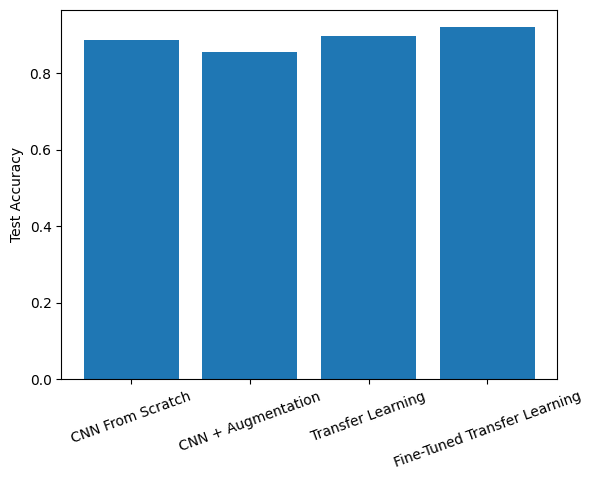

In [98]:
plt.bar(results["Model"], results["Accuracy"])
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20)
plt.show()

### Test Accuracy Comparison

The Fine-Tuned Transfer Learning model achieved the highest test accuracy among all models.

Transfer Learning also performed better than the CNN from scratch, while the CNN with data augmentation achieved the lowest test accuracy in this experiment.

Fine-tuning the pre-trained model improved its performance and produced the best overall accuracy.

### Compare Model Recall

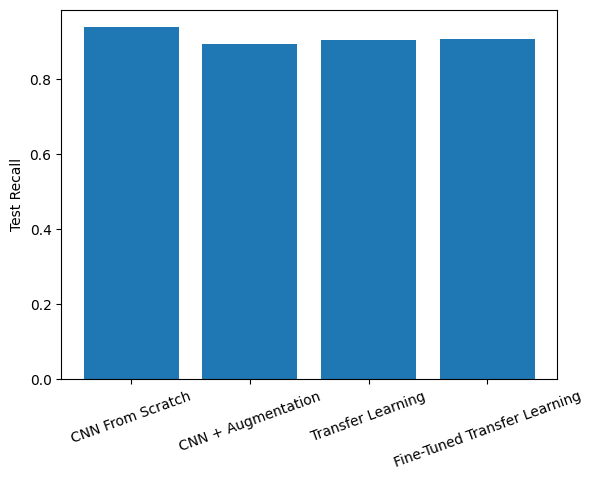

In [99]:
plt.bar(results["Model"], results["Recall"])
plt.ylabel("Test Recall")
plt.xticks(rotation=20)
plt.show()

### Test Recall Comparison

The CNN from scratch achieved the highest test recall among all models.

The Fine-Tuned Transfer Learning model achieved slightly higher recall than the regular Transfer Learning model, while the CNN with data augmentation had the lowest recall in this experiment.

This means the CNN from scratch was the best model for detecting malignant cases, while the Fine-Tuned Transfer Learning model provided a better overall balance across the evaluation metrics.

## Step 4: Document the Best Approach

### Best Performing Approach

The Fine-Tuned Transfer Learning model achieved the best overall performance.

- **Test Accuracy:** 91.90%
- **Test Recall:** 90.90%
- **Test Loss:** 0.2318

It achieved the highest test accuracy and the lowest test loss among all tested models.

The CNN from scratch achieved the highest recall at 93.90%, but the Fine-Tuned Transfer Learning model provided the best overall balance between accuracy, recall, and loss.

Fine-tuning allowed the last layers of the pre-trained MobileNetV2 model to adapt to the melanoma dataset while preserving the useful visual features learned from ImageNet.